<a href="https://colab.research.google.com/github/carlosramos1/ML-Models-implementation/blob/main/SVM_with_cvxopt_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [489]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers
from sklearn.metrics import confusion_matrix

# para comparar con la implementación
from sklearn import svm

# Support Vector Machine

## El problema dual - soft margin

Resolver el siguiente problema de optimización:

$$
\begin{align}
\min_ \alpha \quad
& \frac{1}{2}\alpha^T ((\mathbf y \otimes \mathbf y) \odot \mathbf K)\alpha - \mathbf \alpha \\
\text{sujeto a} \quad & \mathbf -\alpha \leq 0 , \quad \mathbf \alpha \leq C \\
& \mathbf y^T \mathbf \alpha = 0
\end{align}
$$

- El operador $\odot$ indica que es una multiplicación elemento a elemento.
- El operador $\otimes$ indica que es una operación *outer procduct*.


In [490]:
def solve_min_dual(X, y, C=0.1, kernel="linear", gamma=0.5, d=2):
  n = y.shape[0]
  K = calc_kernel(X, X, kernel, gamma, d)

  # Preparación de parámetros
  # función objetivo
  P = matrix(np.outer(y, y) * K )
  q = matrix(-np.ones(n))
  # Restricción desigualdad
  G = matrix(np.vstack([-np.eye(n), np.eye(n)]))
  h = matrix(np.hstack([np.zeros(n), C*np.ones(n)]))
  # Restricción igualdad
  A = matrix(y, (1, n))
  b = matrix(np.zeros(1))

  solvers.options['show_progress'] = False
  solution = solvers.qp(P, q, G, h, A, b)

  # multiplicadores de lagrange (alphas)
  return np.ravel(solution['x'])

## Kernels

- Kernel Lineal: $k(\mathbf x_i, \mathbf x_m) = \mathbf x_i \cdot \mathbf x_m$
- Kernel Polinómico de grado $d$: $k(\mathbf x_i, \mathbf x_m) = (1+ (\mathbf x_i \cdot \mathbf x_m) )^d$
- Kernel de Base Radial o RBF: $k(\mathbf x_i, \mathbf x_m) = \exp{} (-\gamma \|\mathbf x_i - \mathbf x_m\| ^2 )$

In [491]:
def calc_kernel(X1, X2, type="linear", gamma=0.5, d=2):
  K = np.zeros((X1.shape[0], X2.shape[0]))

  if type == "linear":
      for i, xi in enumerate(X1):
          for j, xm in enumerate(X2):
              K[i, j] = np.dot(xi, xm)

  elif type == "rbf":
      for i, xi in enumerate(X1):
          for j, xm in enumerate(X2):
              K[i, j] = np.exp(-gamma * np.linalg.norm(xi - xm) ** 2)

  elif type == "poly":
      for i, xi in enumerate(X1):
          for j, xm in enumerate(X2):
              K[i, j] = (1 + np.dot(xi, xm)) ** d
  return K

### Parámetros $\mathbf w$ y $b$

$$\mathbf{w} = \sum_{i=1}^{n} \alpha_i y_i \mathbf{x}_i$$

In [492]:
def compute_w(alphas, X, y):
  return X.T @ (alphas * y)

$$b= \frac{1}{S} \sum_{i=1}^S \left(y_i - \sum_{s=1}^S \alpha_s y_s K(\mathbf x_s, \mathbf  x_i)\right)$$

In [493]:
def compute_b(X_sv, y_sv, alphas_sv,
                  kernel="linear", gamma=0.5, d=2):
  b = (y_sv) - np.sum(alphas_sv * y_sv *
                      calc_kernel(X_sv, X_sv, kernel, gamma=gamma, d=d), axis=1)
  return np.mean(b)

### Función de predicción

$$
\hat y_j = \operatorname{sign} \left( \sum_{s=1}^S \alpha_s y_s K(\mathbf x_s, \mathbf x_j)+b \right)
$$

In [494]:
def predict(X_new, X_sv, y_sv, alphas_sv, b,
                kernel="linear", gamma=0.5, d=2):
  K = calc_kernel(X_new, X_sv, kernel, gamma, d)
  f = np.sum(alphas_sv * y_sv * K, axis=1) + b
  return np.sign(f)

## Datasets de juguete

In [495]:
def get_dataset_linear():
  n = 1000
  np.random.seed(8888)
  X = np.random.rand(n, 2)
  y = np.zeros(n)
  noise = np.random.uniform(-0.05, 0.05, n)
  for i in range(n):
    x1 = X[i][0]
    x2 = X[i][1] + noise[i]
    y[i] = 1.0 if x2 <= 1.0 * x1 else -1.0

  return X, y

In [496]:
def get_dataset_poly():
  n = 1000
  degree = 3
  np.random.seed(8888)
  noise = np.random.uniform(-0.5, 0.5, n)
  X = np.random.rand(n, 2) * 4 - 2
  y = np.zeros((n,))
  for i in range(n):
    if X[i, 1] > X[i, 0]**degree - noise[i]:  #y = x^3
      y[i] = -1
    else:
      y[i] = 1
  return X, y

In [497]:
def get_dataset_rbf():
  n = 1000
  np.random.seed(8888)
  noise = np.random.uniform(-0.05, 0.05, n)
  X = np.random.rand(n, 2)
  y = np.zeros((n,))
  r = 0.3
  centre = np.array([0.5, 0.5])
  for i in range(n):
      dist = np.linalg.norm(X[i] - centre) + noise[i]
      y[i] = 1.0 if dist <= r else -1.0
  return X, y

## Kernel lineal

### Datos de prueba

In [498]:
# Cargando los datos
X, y = get_dataset_linear()
X.shape, y.shape

((1000, 2), (1000,))

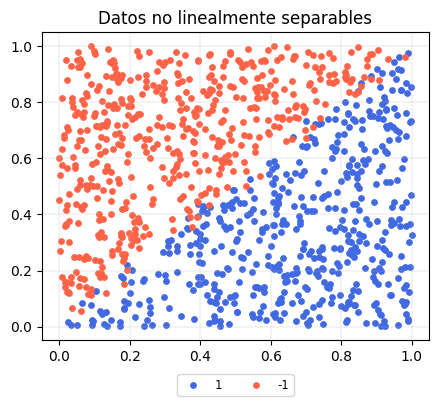

In [499]:
# Graficando los datos
X_pos = X[y == 1]
X_neg = X[y == -1]

plt.figure(figsize=(5, 4))
plt.scatter(X_pos[:, 0], X_pos[:, 1], s=15, color='royalblue', label='1')
plt.scatter(X_neg[:, 0], X_neg[:, 1], s=15, color='tomato', label='-1')

plt.title('Datos no linealmente separables')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2),
           ncol=2, fontsize='small')
plt.grid(True, linewidth=0.2)
plt.show()

### Entrenamiento del modelo

In [500]:
# hiperparámetro C
C = 0.5

# multiplicadores de Lagrange
alphas = solve_min_dual(X, y, C=C, kernel="linear")

# vectores de soporte (alpha > 0)
support_vectors = alphas > 1e-5
alphas_sv = alphas[support_vectors]
X_sv = X[support_vectors]
y_sv = y[support_vectors]

print("Número de vectores de soporte:", y_sv.size)

Número de vectores de soporte: 319


In [501]:
# Calculando los parámetros del hiperplano
w = compute_w(alphas_sv, X_sv, y_sv)
b = compute_b(X_sv, y_sv, alphas_sv, kernel="linear")
print('w: ', w)
print('b: ', b)

w:  [ 6.0538951  -5.90797421]
b:  -0.024945302306971708


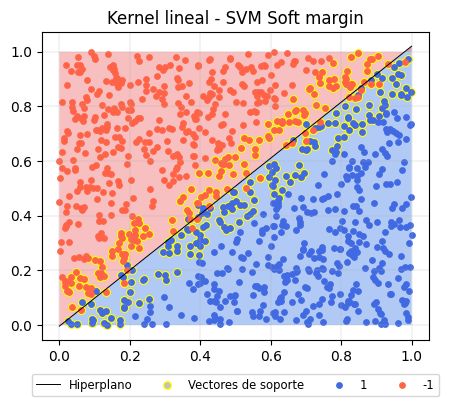

In [503]:
# Graficar el hiperplano y los vectores de soporte
plt.figure(figsize=(5, 4))

# hiperplano
min_x1, max_x1 = X[:, 0].min(), X[:, 0].max()
u = np.linspace(min_x1, max_x1, 100)
v = (-w[0] * u - b) / w[1]
plt.plot(u, v, 'k-', linewidth=.7, label='Hiperplano')

# fondo
plt.fill_between(u, v, min_x1, facecolor="cornflowerblue", alpha=0.5)
plt.fill_between(u, v, max_x1, facecolor="lightcoral", alpha=0.5)

# vectores de soporte
plt.scatter(X_sv[:,0], X_sv[:,1], c="silver", s=30,
            linewidths=1, edgecolors="yellow", label='Vectores de soporte')

# conjunto de datos (X, y) - observaciones
X_pos, X_neg = X[y == 1], X[y == -1]
plt.scatter(X_pos[:, 0], X_pos[:, 1], s=15, color='royalblue', label='1')
plt.scatter(X_neg[:, 0], X_neg[:, 1], s=15, color='tomato', label='-1')

plt.title('Kernel lineal - SVM Soft margin')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2),
           ncol=4, fontsize='small')
plt.grid(True, linewidth=0.2)
plt.show()

### Predicción del modelo

In [452]:
# Predecir para los mismos datos
y_hat = predict(X, X_sv, y_sv, alphas_sv, b, kernel="linear")
y_hat[:10]

array([ 1.,  1., -1.,  1., -1.,  1., -1.,  1., -1.,  1.])

In [453]:
# Matriz de confusión
cm = confusion_matrix(y_hat, y)
print(cm)

[[478  10]
 [ 19 493]]


In [454]:
# Medida de aciertos
(cm[0,0]+cm[1,1])/y.size

np.float64(0.971)

### Comparación con la librería `sklearn`

In [455]:
# Definición del modelo
svm_model = svm.SVC(C=C, kernel='linear')

# Entrenamiento
svm_model.fit(X, np.ravel(y))

SVC(C=0.5, kernel='linear')

In [456]:
# Comparamos los parámteros w y b (hiperplano)
print('implementación:')
print('w: ', w)
print('b: ', b)
print('sklearn:')
print('w: ', svm_model.coef_)
print('b: ', svm_model.intercept_)

implementación:
w:  [ 6.0538951  -5.90797421]
b:  -0.024945302306971708
sklearn:
w:  [[ 6.05314963 -5.90611575]]
b:  [-0.03485044]


In [457]:
# Comparamos la cantidad de vectores de soporte
print('implementación:\t', len(X_sv))
print('sklearn:\t', len(svm_model.support_vectors_))

implementación:	 319
sklearn:	 318


In [458]:
# Predicción y Matriz de confusión
cm_svm = confusion_matrix(y, svm_model.predict(X))
cm_svm

array([[478,  19],
       [ 12, 491]])

In [459]:
# Medida de aciertos
(cm[0,0]+cm[1,1])/y.size

np.float64(0.971)

El resultado de `sklearn.svm` es muy similar a la implementación.

## Kernel polinómico

### Datos de prueba

In [460]:
# Cargando los datos
X, y = get_dataset_poly()
X.shape, y.shape

((1000, 2), (1000,))

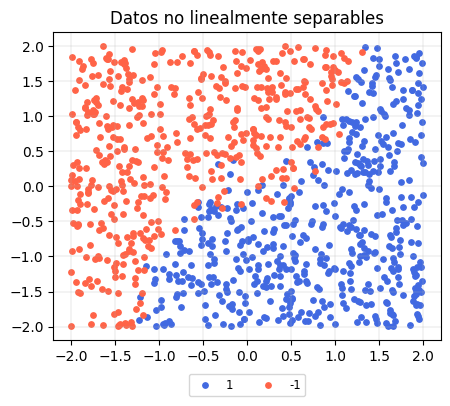

In [461]:
# Graficando los datos
X_pos = X[y == 1]
X_neg = X[y == -1]

plt.figure(figsize=(5, 4))
plt.scatter(X_pos[:, 0], X_pos[:, 1], s=15, color='royalblue', label='1')
plt.scatter(X_neg[:, 0], X_neg[:, 1], s=15, color='tomato', label='-1')

plt.title('Datos no linealmente separables')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2),
           ncol=2, fontsize='small')
plt.grid(True, linewidth=0.2)
plt.show()

### Entrenamiento del modelo

In [462]:
# parámetros
C = 1     # hiperparámetro C
d = 3     # grado del polinomio

# multiplicadores de lagrange
alphas = solve_min_dual(X, y, C=C, kernel="poly", d=d)

# vectores de soporte (alpha > 0)
support_vectors = alphas > 1e-5
alphas_sv = alphas[support_vectors]
X_sv = X[support_vectors]
y_sv = y[support_vectors]

print("Número de vectores de soporte:", y_sv.size)

Número de vectores de soporte: 90


In [463]:
# Cálculo del parámetro b, ¡w sólo es para kernel lineal!
b = compute_b(X_sv, y_sv, alphas_sv, kernel="poly", d=d)
print('b: ', b)

b:  -0.16358066364660231


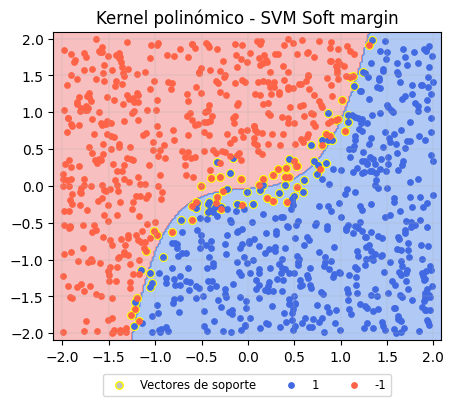

In [465]:
from matplotlib.colors import ListedColormap

# Graficar el límite de separación y los vectores de soporte
plt.figure(figsize=(5, 4))

# límite de decisión
h = .02
x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = predict(np.c_[xx.ravel(), yy.ravel()], X_sv, y_sv,
            alphas_sv, b, kernel="poly", d=d)
Z = Z.reshape(xx.shape)

# fondo
colors = ListedColormap(['lightcoral', 'cornflowerblue'])
plt.contourf(xx, yy, Z, cmap=colors, alpha=0.5)

# vectores de soporte
plt.scatter(X_sv[:,0], X_sv[:,1], c="silver", s=30,
            linewidths=1, edgecolors="yellow", label='Vectores de soporte')

# conjunto de datos X, y (observaciones)
X_pos, X_neg = X[y == 1], X[y == -1]
plt.scatter(X_pos[:, 0], X_pos[:, 1], s=15, color='royalblue', label='1')
plt.scatter(X_neg[:, 0], X_neg[:, 1], s=15, color='tomato', label='-1')

plt.title('Kernel polinómico - SVM Soft margin')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2),
           ncol=4, fontsize='small')
plt.grid(True, linewidth=0.2)
plt.show()

### Predicción del modelo

In [466]:
# Predecir para los mismos datos
y_hat = predict(X, X_sv, y_sv, alphas_sv, b, kernel="poly", d=d)
y_hat[:10]

array([ 1.,  1.,  1., -1., -1.,  1.,  1.,  1., -1.,  1.])

In [467]:
# Matriz de confusión
cm = confusion_matrix(y_hat, y)
print(cm)

[[469  14]
 [ 16 501]]


In [468]:
# Medida de aciertos
(cm[0,0]+cm[1,1])/y.size

np.float64(0.97)

### Comparacion con la libreria sklearn

In [469]:
# Definición del modelo
svm_model = svm.SVC(C=C, kernel='poly', degree=d, coef0=1, gamma=1)
# sklearn implementa una variante del poly, por eso coef0=1, gamma=1

# Entrenamiento
svm_model.fit(X, np.ravel(y))

SVC(C=1, coef0=1, gamma=1, kernel='poly')

In [470]:
#svm_model.coef_  #error: coef_ is only available when using a linear kernel

In [471]:
# Comparamos el parámetro b
print('implementación:\t', b)
print('sklearn:\t', svm_model.intercept_)

implementación:	 -0.16358066364660231
sklearn:	 [-0.15489363]


In [472]:
# Comparamos la cantidad de support vectors
print('implementación:\t', len(X_sv))
print('sklearn:\t', len(svm_model.support_vectors_))

implementación:	 90
sklearn:	 90


In [473]:
# Predicción y Matriz de confusión
yp_hat = svm_model.predict(X)
cm_svm = confusion_matrix(y, yp_hat)
cm_svm

array([[468,  17],
       [ 14, 501]])

In [474]:
# Medida de aciertos
(cm[0,0]+cm[1,1])/y.size

np.float64(0.97)

Los resultados son muy similares

## Kernel RBF

### Datos de prueba

In [475]:
# Cargando los datos
X, y = get_dataset_rbf()
X.shape, y.shape

((1000, 2), (1000,))

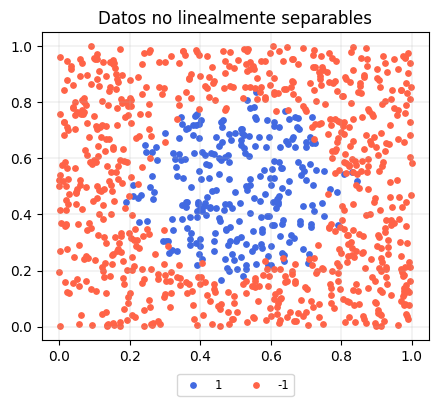

In [476]:
# Graficando los datos
X_pos = X[y == 1]
X_neg = X[y == -1]

plt.figure(figsize=(5, 4))
plt.scatter(X_pos[:, 0], X_pos[:, 1], s=15, color='royalblue', label='1')
plt.scatter(X_neg[:, 0], X_neg[:, 1], s=15, color='tomato', label='-1')

plt.title('Datos no linealmente separables')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2),
           ncol=2, fontsize='small')
plt.grid(True, linewidth=0.2)
plt.show()

### Entrenamiento del modelo

In [477]:
# parámetros
C = 10        # hiperparámetro C
gamma = 0.5  # parámetro del kernel RBF

# multiplicadores de lagrange
alphas = solve_min_dual(X, y, C=C, kernel="rbf", gamma=gamma)

# vectores de soporte (alpha > 0)
support_vectors = alphas > 1e-5 # OJO con 1e-7 no daba, 1e-5 mejoró
alphas_sv = alphas[support_vectors]
X_sv = X[support_vectors]
y_sv = y[support_vectors]

print("Número de vectores de soporte:", y_sv.size)

Número de vectores de soporte: 299


In [478]:
# Cálculo del parámetro b, ¡w sólo es para kernel lineal!
b = compute_b(X_sv, y_sv, alphas_sv, kernel="rbf", gamma=gamma)
print('b: ', b)

b:  -22.871570545569437


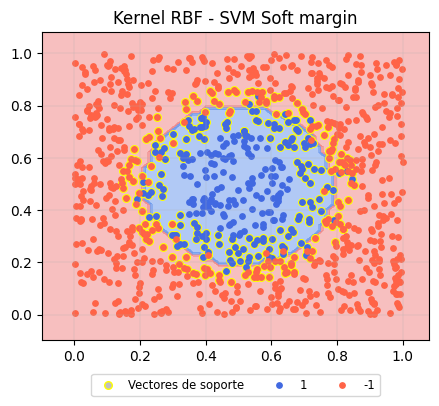

In [479]:
from matplotlib.colors import ListedColormap

# Graficar el límite de separación y los vectores de soporte
plt.figure(figsize=(5, 4))

# límite de decisión
h = .02
x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = predict(np.c_[xx.ravel(), yy.ravel()], X_sv, y_sv,
            alphas_sv, b, kernel="rbf", gamma=gamma)
Z = Z.reshape(xx.shape)

# fondo
colors = ListedColormap(['lightcoral', 'cornflowerblue'])
plt.contourf(xx, yy, Z, cmap=colors, alpha=0.5)

# vectores de soporte
plt.scatter(X_sv[:,0], X_sv[:,1], c="silver", s=30,
            linewidths=1, edgecolors="yellow", label='Vectores de soporte')

# conjunto de datos X, y (observaciones)
X_pos, X_neg = X[y == 1], X[y == -1]
plt.scatter(X_pos[:, 0], X_pos[:, 1], s=15, color='royalblue', label='1')
plt.scatter(X_neg[:, 0], X_neg[:, 1], s=15, color='tomato', label='-1')

plt.title('Kernel RBF - SVM Soft margin')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2),
           ncol=4, fontsize='small')
plt.grid(True, linewidth=0.2)
plt.show()

### Predicción del modelo

In [480]:
# Predecir para los mismos datos
y_hat = predict(X, X_sv, y_sv, alphas_sv, b, kernel="rbf", gamma=gamma)
y_hat[:10]

array([-1., -1., -1., -1., -1.,  1., -1.,  1., -1.,  1.])

In [481]:
# Matriz de confusión
cm = confusion_matrix(y_hat, y)
print(cm)

[[723  20]
 [ 17 240]]


In [482]:
# Medida de aciertos
(cm[0,0]+cm[1,1])/y.size

np.float64(0.963)

### Comparacion con la libreria sklearn

In [483]:
# Definición del modelo
svm_model = svm.SVC(C=C, kernel='rbf', gamma=gamma)

# Entrenamiento
svm_model.fit(X, np.ravel(y))

SVC(C=10, gamma=0.5)

In [484]:
#svm_model.coef_  #error: coef_ is only available when using a linear kernel

In [485]:
# Comparamos el parámetro b
print('implementación:\t', b)
print('sklearn:\t', svm_model.intercept_)

implementación:	 -22.871570545569437
sklearn:	 [-22.95559056]


In [486]:
# Comparamos la cantidad de support vectors
print('implementación:\t', len(X_sv))
print('sklearn.svm:\t', len(svm_model.support_vectors_))

implementación:	 299
sklearn.svm:	 274


In [487]:
# Predicción y Matriz de confusión
yp_hat = svm_model.predict(X)
cm_svm = confusion_matrix(y, yp_hat)
cm_svm

array([[726,  14],
       [ 23, 237]])

In [488]:
# Medida de aciertos
(cm[0,0]+cm[1,1])/y.size

np.float64(0.963)

Los resultados son muy similares

## Consideraciones finales

- Los parámetros $b$ y $w$ calculados con esta implementación y los obtenidos con `sklearn.svm` son muy similares.
- Tanto esta implementación como la de `sklearn.svm` obtuvieron casi la misma cantidad de aciertos y fracasos en la clasificación (se hizo la comparación mediante la matriz de confusión).
- En el caso del kernel polinómico, la implementación de `sklearn.svm` tiene una leve variación respecto a esta implementación:
  - *sklearn* lo plantea como: $k(\mathbf x_i, \mathbf x_m) = (\gamma(\mathbf x_i \cdot \mathbf x_m) + r )^d$ https://scikit-learn.org/stable/modules/svm.html#kernel-functions
  - en cambio esta implementación: $k(\mathbf x_i, \mathbf x_m) = (1+ (\mathbf x_i \cdot \mathbf x_m) )^d$ (Según el libro The elements of statistical ML - Hastie, Tibshirani, Friedman, p. 424)

- El tiempo de ejecución del entrenamiento con `sklearn.svm` es mucho menor a esta implementación, era de esperarse porque esta implementación es solamente demostratíva y didáctica.

  